What is Pydantic?
- Pydantic (library) = Data validation + parsing using Python type hints
- In python specifying int, str refers to type hints
- It auto-converts, validates, and raises errors

Why its important ?
- Validates request body
- Parses JSON → Python objects

### Basic Model


In [4]:
from pydantic import BaseModel

class User(BaseModel):
    id: int
    name: str
    is_active: bool

#### Type conversions

In [5]:
user = User(id="1", name="John Doe", is_active="true")
print(user)
print(type(user))
print(type(user.id))

id=1 name='John Doe' is_active=True
<class '__main__.User'>
<class 'int'>


#### Validation Errors

In [ ]:
user = User(id="abc", name="John Doe", is_active="true")
print(user)

# Raises Error
# ValidationError: 1 validation error for User id

#### Default Values and optional values




In [8]:
class User(BaseModel):
    id: int
    name: str = "Guest"

user1 = User(id=1)
print(user1)

from typing import Optional

class User(BaseModel):
    id: int
    name: Optional[str] = None

user2 = User(id=2)
print(user2)
user3=User(id=3, name="Alice")
print(user3)

id=1 name='Guest'
id=2 name=None
id=3 name='Alice'


#### Feild Validation with constraints
✔ Constraints:

- gt → greater than
- lt → less than
- min_length
- max_length

In [10]:
from pydantic import Field

class User(BaseModel):
    age: int = Field(gt=0, lt=100)

user = User(age=25)
print(user)
# user=User(age=-5)  # Raises error: age must be greater than 0

age=25


#### custom validator

In [11]:
from pydantic import field_validator

class User(BaseModel):
    name: str

    @field_validator("name")
    def name_must_be_upper(cls, v):
        return v.upper()

user = User(name="John Doe")
print(user)

name='JOHN DOE'


#### Model -> Dict/Json


In [12]:
# user.dict()
# user.json()

C:\Users\disha.agrawal\AppData\Local\Temp\ipykernel_15156\3568493092.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  user.dict()
C:\Users\disha.agrawal\AppData\Local\Temp\ipykernel_15156\3568493092.py:2: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  user.json()


'{"name":"JOHN DOE"}'

In [13]:
user.model_dump()
user.model_dump_json()

'{"name":"JOHN DOE"}'

#### Nested Models

In [14]:
class Address(BaseModel):
    city: str
    pincode: int

class User(BaseModel):
    name: str
    address: Address

address = Address(city="New York", pincode=12345)
user = User(name="John Doe", address=address)
print(user)

name='John Doe' address=Address(city='New York', pincode=12345)


#### List / Complex Types

In [16]:
from typing import List

class User(BaseModel):
    hobbies: List[str]

user = User(hobbies=["Reading", "Traveling"])
print(user)

hobbies=['Reading', 'Traveling']


#### Strict Types

In [17]:
from pydantic import StrictInt

class User(BaseModel):
    age: StrictInt

user = User(age=25)  # Valid
print(user)
# user = User(age="25")  # Raises error: age must be an integer

age=25


#### . Aliases (JSON → Python mapping)

In [19]:
class User(BaseModel):
    user_name: str = Field(alias="username")

user = User(username="john_doe")
print(user)

user_name='john_doe'


#### Pydantic V2


In [25]:
from pydantic import computed_field

class User(BaseModel):
    first: str
    last: str

    @property
    # @computed_field
    def full_name(self):
        return f"{self.first} {self.last}"

user = User(first="John", last="Doe")
print(user.full_name)


John Doe


# ⚡ Pydantic v1 vs v2 (Important)

## 🔍 Key Differences

| Feature        | v1              | v2                |
|----------------|----------------|-------------------|
| Validators     | `@validator`   | `@field_validator`|
| Speed          | Slower         | Much faster ⚡     |
| Core Engine    | Python         | Rust              |

---

## 🧠 Mental Model (Very Important)

Think of Pydantic as a pipeline:

raw input (Json) - > Pydantic -> python validated object
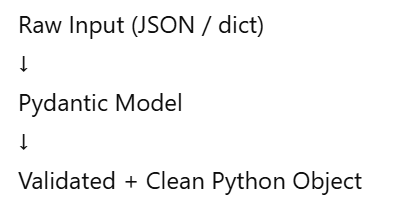
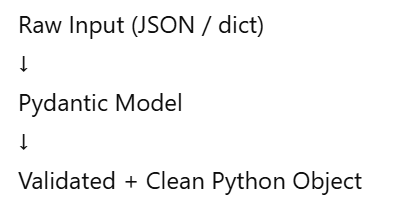